In [172]:
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [173]:
data = pd.read_csv("Data/riceClassification.csv")
data.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


## Preprocessing 

In [174]:
data.dropna(inplace=True)
data.drop(['id'], axis=1, inplace=True)
data

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1
...,...,...,...,...,...,...,...,...,...,...,...
18180,5853,148.624571,51.029281,0.939210,6008,86.326537,0.498594,332.960,0.663444,2.912535,0
18181,7585,169.593996,58.141659,0.939398,7806,98.272692,0.647461,385.506,0.641362,2.916910,0
18182,6365,154.777085,52.908085,0.939760,6531,90.023162,0.561287,342.253,0.682832,2.925396,0
18183,5960,151.397924,51.474600,0.940427,6189,87.112041,0.492399,343.371,0.635227,2.941216,0


In [175]:
print(data['Class'].unique())
print(data["Class"].value_counts())

[1 0]
Class
1    9985
0    8200
Name: count, dtype: int64


- Here we will normalize the data because the weights are smaller compared to the dataset values, the weights will be multiplied with the inputs, so they will get huge and slower.
- We will make each column to be the max value = 1.


In [176]:
original_df = data.copy()

for column in data.columns:
    data[column] = data[column] / data[column].max() # Divide each value of each column with the max value of each column
data.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [177]:

# : (Before the comma): This tells Python to keep all rows.
# : (Inside the slice): The colon indicates a range from the start to a specific stop point.
# -1 (Inside the slice): This represents the very last element or index. 

# Inputs
X = np.array(data.iloc[:, :-1]) # Take all the column from the first one unitl the end except the last column in the data

# Output
y = np.array(data.iloc[:, -1])


In [178]:
# Spliting the data 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

In [179]:
# We will split the testing data (which is 30%) into 50% testing and 50% validation 
# Validation set --> You use validation data while developing the model. You check the validation score and make improvements.
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5)
# Test set --> "How good is this model on data it has never seen?" / The test set should be untouched during development.


# Why not just use validation data?
# Because if you repeatedly check validation performance and change your model based on it, your model starts indirectly adapting to the validation set.

In [180]:
print(X_train.shape)

(12729, 10)


**Dataset**
- PyTorch is like a whole separate system, so we need to convert our pandas dataset object into PyTorch dataset object.
- Pandas stores / clean / manipulate the data, However, Dataset from PyTorch prepares data for training.
- When you train a neural network, PyTorch doesn't want a DataFrame. It wants data in a format that it can efficiently feed to the model which is Dataset.
- **Dataset** makes your data work smoothly with PyTorch's training tools, especially **DataLoader**.
- **Dataset** with PyTorch gives a standard way to access your data.
- **Dataset** makes shuffling and getting specific samples and splitting the data into batches easier.
- **Dataset** Stores data and fetches items by index.

In [181]:
class MyDataset(Dataset):
    # Dataset class already has methods, we will override them and modify some of them to match our data properties

    def __init__(self, X, y): # Take the inputs and the output 
        self.X = torch.tensor(X, dtype=torch.float32).to(device) # to dvice --> GPU
        self.y = torch.tensor(y, dtype=torch.float32).to(device)

    # Override from the parent, so it matches our data
    def __len__(self):
        return len(self.X) # returns the total number of samples in the dataset

    # Override
    def __getitem__(self, index): # returns one sample given its index.
        return self.X[index], self.y[index]


In [182]:
# Converts the data into PyTorch tensors and use the other methods 
training_data = MyDataset(X_train, y_train)
validation_data = MyDataset(X_val, y_val)
testing_data = MyDataset(X_test, y_test)

- **DataLoader** Creates batches, shuffels data, feeds GPU efficiently.
- We use DataLoader because neural networks usually do not train on the entire dataset at once.
  - It split data into small batches (e.g., 8 samples at a time) so your GPU/memory can handle it.
  - Shuffle the data so the model does not memorize the order.
  - Feed the data automatically into the training loop.
- **Dataset** stores your data, and **DataLoader** delivers it to the model in manageable batches during training.

In [183]:
# This means pick 8 samples from the training dataset. Then, put them together into one batch.
# The DataLoader returns one batch at a time by default. 
train_dataloader = DataLoader(training_data, batch_size = 32, shuffle = True) # will automate batching and shuffling
validation_dataloader = DataLoader(training_data, batch_size = 32, shuffle = True)
testing_dataloader = DataLoader(training_data, batch_size = 32, shuffle = True)

In [184]:
# Building the model 
HIDDEN_NEURONS = 10 # The number of neurons in the hidden layer of your neural network.
class MyModel(nn.Module):
    
    def __init__(self):

        super(MyModel, self).__init__()
    
        # This layer will recive 10 features and will forward them into 10 neurons.
        self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS)
        # shape[1] will give you the number of features (columns).
        # The neural network does not need to receive all samples at once. It receives one sample at a time
        # or a batch of samples, and each sample contains all its features.
        # This means each sample I receive will have 10 features.
        # # The hidden layer. It will has 10 neurons.
        
        # The output layer. 10 neurons to the output neuron 
        self.linear = nn.Linear(HIDDEN_NEURONS, 1)

        # Its job is to convert the output into a probability between 0 and 1.
        self.sigmoid = nn.Sigmoid()

    # Define how the data will flow
    def forward(self, x):
    # The flow of the data
        x = self.input_layer(x) # First the data will go to the input layer
        x = self.linear(x) # The output will go to the linear layer (the output layer)
        x = self.sigmoid(x) # The output of the hidden layer will go to the sigmoid function
        return x

model = MyModel().to(device)


Input Sample

(10 features)

[ x1, x2, x3, ..., x10 ]

          |
          ↓

Linear Layer

nn.Linear(10, 10)

          |
          ↓

Hidden Layer

[ h1, h2, h3, ..., h10 ]

          |
          ↓

Output Layer

nn.Linear(10, 1)

          |
          ↓

Raw Output

Example: 2.5

          |
          ↓

Sigmoid

          |
          ↓

Probability

Example: 0.92


<br>
<br>



10 Input Features

        |
        ↓

10 Hidden Neurons

        |
        ↓

1 Output Neuron

        |
        ↓

Sigmoid Activation

        |
        ↓
        
Probability (0 - 1)

In [185]:
# Takes the model and the input shape 
summary(model, (X.shape[1],))

Layer (type:depth-idx)                   Output Shape              Param #
MyModel                                  [1]                       --
├─Linear: 1-1                            [10]                      110
├─Linear: 1-2                            [1]                       11
├─Sigmoid: 1-3                           [1]                       --
Total params: 121
Trainable params: 121
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [186]:
criterion = nn.BCELoss() # Binay cross entropy loss
optimizer = Adam(model.parameters(), lr=1e-3)

In [187]:
# Training and validation
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

# Training 
epochs = 10
for epoch in range(epochs):
    # These variables collect the totals only for the current epoch.
    # They will be assigned to 0 at the beginning of every epoch.
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0


    # 1000 samples
    # Batch size = 100
    # The DataLoader produces:
    # Batch 1 → 100 samples
    # Batch 2 → 100 samples
    # Batch 3 → 100 samples
    # ...
    # Batch 10 → 100 samples


    # The loop processes one batch at a time.
    for data in train_dataloader:
        inputs, labels = data # Every epoch will contains 2 things: inputs --> the model will recevie. Labels are the correct answers.


        # This is the forward pass, the model wil take the inputs and predict.
        prediction = model(inputs).squeeze(1) # .squeez(1) to make the shape of the prediction same as the label
        batch_loss = criterion(prediction, labels) # Get the loss value using the BCE.


        # Store the loss of this batch for this epoch, after all batches are done you know the total loss for the epoch.
        total_loss_train += batch_loss.item()

        # prediction.round() will convert the prediction to 0s and 1s, then compare with the true labels, then sum
        # the correct prediction
        acc = ((prediction).round() == labels).sum().item()

        total_acc_train += acc


    # Backpropagation: It computes the gradient of the loss with respect to every trainable parameter in the model.

    # The gradients tell each weight:
    # Should it increase or decrease?
    # By how much would changing it reduce the loss?
    # This step does not change the weights yet. It only calculates the gradients.
        batch_loss.backward()

    # Now the optimizer uses those gradients to modify the model's parameters.
    # Like: new weight = old weight − learning rate × gradient
    # This is the moment when the model actually learns from the current batch.
        optimizer.step()

    # PyTorch accumulates gradients by default. Without zero_grad() batch 1 gradient will add to batch 2 graident and so on.
    # you want each batch to start with fresh gradients, so you clear them after updating the weights. Bceause 
    # this will make updating the weight and converging the model faster and correctly.
        optimizer.zero_grad()



    # Validation



    # Training data teaches the model. Validation data checks whether the model is actually learning something useful.
    # During training, the model sees the training data. Calculate the loss, and the model changes its weights.

    # To detect the overfittign, we use validation data (the model never seen them). 
    
    # In one epoch: 


    # Step 1: The model trains on all 1000 samples and do backward and updates the weights.

#     Forward
#       ↓
#      Loss
#       ↓
#   Backward
#       ↓
# Update weights


    # Step 2: Training is finished for this epoch. Now, Let's see how well the model perform on data you've never seen
    # So we give it the 200 validation samples. 

    #  Forward
    #     ↓
    #   Loss
    #     ↓   
    # Accuracy

    # Notice there is no backward() and optimizer.step(). The model does not learn from these examples.
    # It only answers them.

    # torch.no_grad() --> we are only evaluating the model. Do not calculate gradients.
    # Normally PyTorch prepares everything needed for learning. During validation we don't want learning. 
    # We only want predictions. 
    with torch.no_grad(): # Don't calculate gradients because I'm not going to update the model.
        for data in validation_dataloader:
            inputs, labels = data

            prediction = model(inputs).squeeze(1)

            batch_loss = criterion(prediction, labels)

            total_loss_val += batch_loss.item()

            acc = ((prediction).round() == labels).sum().item()

            total_acc_val += acc

    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_loss_validation_plot.append(round(total_loss_val/1000, 4))
    total_acc_train_plot.append(round(total_acc_train/(training_data.__len__())*100, 4))
    total_acc_validation_plot.append(round(total_acc_val/(validation_data.__len__())*100, 4))

    print("Correct predictions:", total_acc_val)
    print("Validation dataset length:", len(validation_data))   
    print("Number of validation batches:", len(validation_dataloader))

    print(f'''Epoch no. {epoch + 1} Train Loss: {total_loss_train/1000:.4f} Train Accuracy: {(total_acc_train/(training_data.__len__())*100):.4f} Validation Loss: {total_loss_val/1000:.4f} Validation Accuracy: {(total_acc_val/(validation_data.__len__())*100):.4f}''')
    print("="*50)
    


Correct predictions: 12518
Validation dataset length: 2728
Number of validation batches: 398
Epoch no. 1 Train Loss: 0.2414 Train Accuracy: 78.0737 Validation Loss: 0.1899 Validation Accuracy: 458.8710
Correct predictions: 12470
Validation dataset length: 2728
Number of validation batches: 398
Epoch no. 2 Train Loss: 0.1276 Train Accuracy: 97.8553 Validation Loss: 0.0787 Validation Accuracy: 457.1114
Correct predictions: 12542
Validation dataset length: 2728
Number of validation batches: 398
Epoch no. 3 Train Loss: 0.0571 Train Accuracy: 98.2874 Validation Loss: 0.0430 Validation Accuracy: 459.7507
Correct predictions: 12539
Validation dataset length: 2728
Number of validation batches: 398
Epoch no. 4 Train Loss: 0.0356 Train Accuracy: 98.4288 Validation Loss: 0.0304 Validation Accuracy: 459.6408
Correct predictions: 12534
Validation dataset length: 2728
Number of validation batches: 398
Epoch no. 5 Train Loss: 0.0277 Train Accuracy: 98.4052 Validation Loss: 0.0250 Validation Accuracy:

### Testing

In [190]:
# Same code as the trainging and validation but its only for one time, not for every epoch 

with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0

    for data in testing_dataloader:
        inputs, labels = data

        prediction = model(inputs).squeeze(1)

        batch_loss_test = criterion(prediction, labels).item() # items() will convert the tensor to python number
        total_loss_test += batch_loss_test

        acc = ((prediction).round() == labels).sum().item()

        total_acc_test += acc

print("Accuracy: ", round(total_acc_test / testing_data.__len__() * 100, 4))

Accuracy:  460.044


| Dataset        | Purpose                        | Does the model learn from it? | When is it used?                 |
| -------------- | ------------------------------ | ----------------------------- | -------------------------------- |
| **Training**   | Teach the model                | ✅ Yes                         | Every epoch                      |
| **Validation** | Check the model while training | ❌ No                          | Every epoch (after training)     |
| **Test**       | Final evaluation               | ❌ No                          | Once, after training is finished |


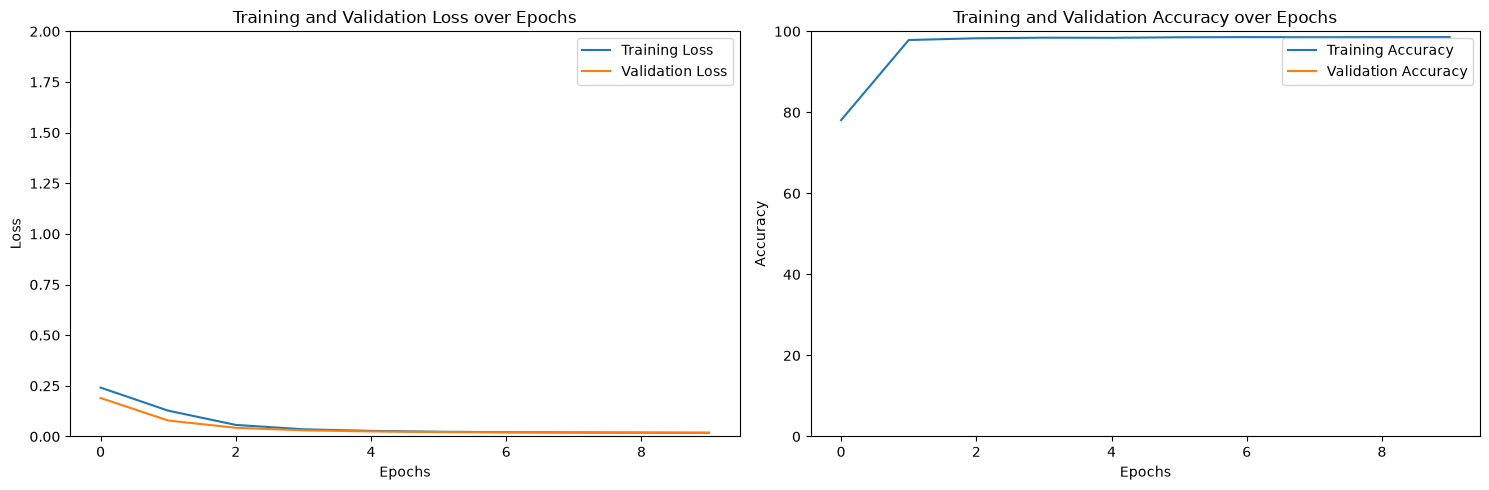

In [191]:

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0, 2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()

plt.show()

### Inference 
- inference means making predictions like you are in production.

- Why is normalization necessary?
  
    During training, the model learned using normalized values, not the original numbers.

In [ ]:


Area = 2353 / original_df['Area'].max()
MajorAxisLength = 81 / original_df['MajorAxisLength'].max()
MinorAxisLength = 42 / original_df['MinorAxisLength'].max()
Eccentricity =  32 / original_df['Eccentricity'].max()
ConvexArea = 12 / original_df['ConvexArea'].max()
EquivDiameter = 33 / original_df['EquivDiameter'].max()
Extent = 98 / original_df['Extent'].max()
Perimeter = 952 / original_df['Perimeter'].max()
Roundness = 658 / original_df['Roundness'].max()
AspectRation = 24 / original_df['AspectRation'].max()

my_prediction = model(torch.tensor([Area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, EquivDiameter, Extent, Perimeter, Roundness, AspectRation], dtype = torch.float32).to(device))

In [198]:
round(my_prediction.item())

0